In [1]:
import numpy as np
import itertools
import matplotlib.pyplot as plt

In [2]:
# ---- Classical linear code definition ----
# Parity-check matrix H (shape (n-k) x n). Default: [3,1,3] repetition code.
H = np.array([[1, 1, 0],
              [0, 1, 1]]) % 2
n   = H.shape[1]          # number of physical bits   (3)
m   = H.shape[0]          # number of checks = n - k  (2)
k   = n - m               # logical bits              (1)
dim = 2 ** n              # state-space dimension      (8)

I2 = np.eye(2)
X  = np.array([[0., 1.], [1., 0.]])          # Pauli X = classical bit flip

def x_string(bits):
    """X^bits = tensor product of X on every position where bits[j]==1."""
    M = np.array([[1.0]])
    for b in bits:
        M = np.kron(M, X if b else I2)
    return M

def syndrome(e):
    """Syndrome H e (mod 2) of an n-bit error pattern e, returned as a tuple."""
    return tuple((H @ np.array(e)) % 2)

def build_decoder(H, n):
    """Minimum-weight lookup decoder: syndrome -> correction bitstring."""
    m = H.shape[0]
    table = {}
    for w in range(n + 1):                       # errors in order of increasing weight
        for combo in itertools.combinations(range(n), w):
            e = np.zeros(n, dtype=int)
            for i in combo:
                e[i] = 1
            s = tuple((H @ e) % 2)
            if s not in table:                   # keep first (lowest-weight) representative
                table[s] = e
        if len(table) == 2 ** m:
            break
    return table

decoder = build_decoder(H, n)

def R_op(s):
    """Recovery operator R_s = X^{corr(s)} for syndrome s."""
    return x_string(decoder[tuple(np.array(s) % 2)])

{s: list(c) for s, c in decoder.items()}     # show the decoding table

{(np.int64(0), np.int64(0)): [np.int64(0), np.int64(0), np.int64(0)],
 (np.int64(1), np.int64(0)): [np.int64(1), np.int64(0), np.int64(0)],
 (np.int64(1), np.int64(1)): [np.int64(0), np.int64(1), np.int64(0)],
 (np.int64(0), np.int64(1)): [np.int64(0), np.int64(0), np.int64(1)]}

In [3]:
# ---- Error model ----
# Independent bit-flip with parameter q, applied both to the n-bit error pattern e~
# and (directly) to the (n-k)-bit syndrome label e_i.
def p_error(e, q):
    """p(e~) = prod_j q^{e_j} (1-q)^{1-e_j} for an n-bit error pattern e."""
    w = int(np.sum(e))
    return q ** w * (1 - q) ** (n - w)

def syndrome_dist(q):
    """Syndrome-label distribution p(e_i): each of the (n-k) syndrome bits is an
    independent bit-flip(q).  Same iid form as p_error, applied to the length-(n-k)
    syndrome bitstring (NOT induced from the error distribution)."""
    return {e: q ** int(sum(e)) * (1 - q) ** (m - int(sum(e))) for e in S}

S = list(itertools.product([0, 1], repeat=m))   # all 2^(n-k) syndrome labels

In [4]:
# ---- Channel construction via superoperators ----
# Column-major vectorization: the map  rho -> K rho K^dagger  becomes  (K* (x) K) vec(rho).
def to_super(K):   return np.kron(K.conj(), K)
def vec(rho):      return rho.reshape(-1, order='F')
def unvec(v):      return v.reshape(dim, dim, order='F')
ISUP = np.eye(dim * dim, dtype=complex)          # identity superoperator (channel at t=0)

def build_SQ(q):
    """SQ[ei][eim1] = superoperator of  Q(e_i, e_{i-1})[rho]
       = sum_{e~} p(e~) R_s X^{e~} rho X^{e~} R_s,  with s = (H e~ + e_i + e_{i-1}) mod 2.
    Note: this shifts the state's syndrome by exactly e_i (+) e_{i-1} (the error e~ cancels,
    because H corr(s) = s), so the syndrome is *updated* each step, not reset."""
    SQ = {ei: {} for ei in S}
    for ei in S:
        for eim1 in S:
            acc = np.zeros((dim * dim, dim * dim), dtype=complex)
            for et in itertools.product([0, 1], repeat=n):
                s = tuple((np.array(syndrome(et)) + np.array(ei) + np.array(eim1)) % 2)
                U = R_op(s) @ x_string(et)       # recovery composed with the error
                acc += p_error(et, q) * to_super(U)
            SQ[ei][eim1] = acc
    return SQ

def build_all_channels(T, q):
    """Cache the superoperator of the dynamical map  channel(t)  for t = 0..T.

    channel(t) = sum_{e1..et} p(e1)..p(et) Q(et,e_{t-1})..Q(e2,e1) R(e1)   (channel(1) = R(e1)).

    This is the *partial product* of the single trajectory: each snapshot ends with the
    latest Q (NOT a trailing recovery), so the syndrome tracks e_t step by step instead of
    being reset to the input. The terminal decode R(e_T) of the full process is applied only
    once at readout and is intentionally NOT part of these intermediate snapshots.
    Built by a transfer-matrix recursion over the syndrome path e1 -> ... -> et."""
    psyn = syndrome_dist(q)
    SR   = {e: to_super(R_op(e)) for e in S}     # recovery superoperators (used for R(e1))
    SQ   = build_SQ(q)
    chans = {0: ISUP.copy()}                      # channel(0) = identity
    C = {e: psyn[e] * SR[e] for e in S}           # state after the initial R(e1), weighted by p(e1)
    chans[1] = sum(C[e] for e in S)               # t=1: a sing
    # le recovery R(e1)
    for t in range(2, T + 1):
        C = {ei: psyn[ei] * sum(SQ[ei][eim1] @ C[eim1] for eim1 in S) for ei in S}
        chans[t] = sum(C[e] for e in S)           # partial product up to Q(e_t,e_{t-1}); no trailing R
    return chans

def make_channel(chans):
    """Wrap the cached superoperators as a callable channel(t, rho)."""
    return lambda t, rho: unvec(chans[t] @ vec(rho))

In [5]:
# ---- Non-Markovianity (BLP) measure ----
# trace_norm(diag(p1-p2)) = ||p1-p2||_1 = 2 * total-variation distance for the classical case.
def trace_norm(A):
    return np.sum(np.abs(np.linalg.eigvalsh(A)))

def non_markovian_measure(channel, T, rho1, rho2):
    rho = rho1 - rho2
    measure = 0
    for t in range(1, T):
        measure += max(0, 0.5 * (trace_norm(channel(t, rho)) - trace_norm(channel(t - 1, rho))))

    return measure

In [6]:
# ---- Sweep rho1, rho2 over all physical basis states; find the maximum ----
def basis_state(i):
    """Pure computational-basis state |i><i| as a diagonal density matrix."""
    rho = np.zeros((dim, dim), dtype=complex)
    rho[i, i] = 1.0
    return rho

def max_measure(T, q):
    """Maximum non-Markovian measure over all pairs of basis states, plus the optimal pair."""
    channel = make_channel(build_all_channels(T, q))
    best_val, best_pair = -1.0, None
    for i in range(dim):
        for j in range(i + 1, dim):
            v = non_markovian_measure(channel, T, basis_state(i), basis_state(j))
            if v > best_val:
                best_val, best_pair = v, (i, j)
    return best_val, best_pair

T = 12
q = 0.1
val, (i, j) = max_measure(T, q)
print(f"code: n={n}, k={k}   T={T}   q={q}")
print(f"max non-Markovian measure = {val:.6f}")
print(f"optimal state pair: |{i:0{n}b}>  vs  |{j:0{n}b}>")

code: n=3, k=1   T=12   q=0.1
max non-Markovian measure = 0.000000
optimal state pair: |100>  vs  |101>


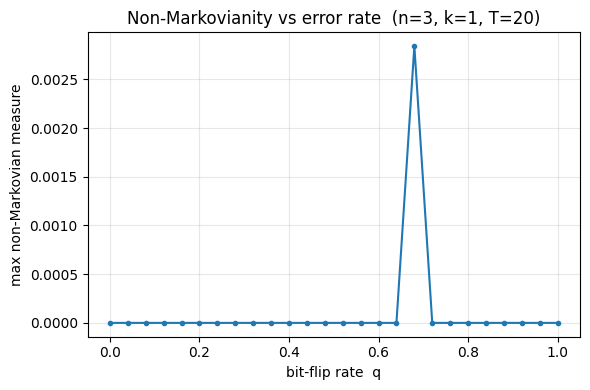

In [7]:
# ---- Sweep the bit-flip rate q and plot the maximised measure ----
T  = 20
qs = np.linspace(0.0, 1.0, 26)
vals = [max_measure(T, q)[0] for q in qs]

plt.figure(figsize=(6, 4))
plt.plot(qs, vals, marker='o', ms=3)
plt.xlabel('bit-flip rate  q')

plt.ylabel('max non-Markovian measure')
plt.title(f'Non-Markovianity vs error rate  (n={n}, k={k}, T={T})')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

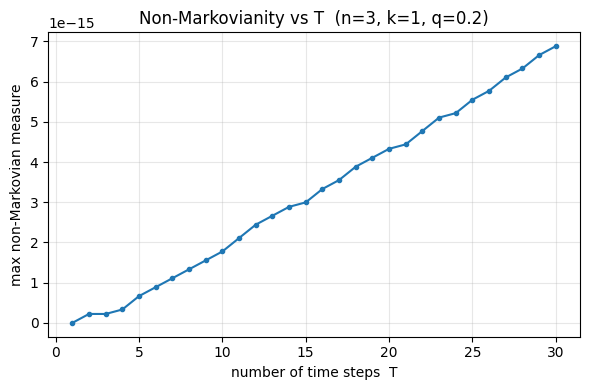

In [8]:
# ---- Measure vs number of time steps T (at fixed q) ----
q    = 0.2
Tmax = 30
channel = make_channel(build_all_channels(Tmax, q))   # build once, reuse for every T

def max_measure_fixed(channel, T):
    """Max non-Markovian measure over basis-state pairs, reusing a prebuilt channel."""
    best = -1.0
    for i in range(dim):
        for j in range(i + 1, dim):
            best = max(best, non_markovian_measure(channel, T, basis_state(i), basis_state(j)))
    return best

Ts   = list(range(1, Tmax + 1))
vals = [max_measure_fixed(channel, T) for T in Ts]

plt.figure(figsize=(6, 4))
plt.plot(Ts, vals, marker='o', ms=3)
plt.xlabel('number of time steps  T')
plt.ylabel('max non-Markovian measure')
plt.title(f'Non-Markovianity vs T  (n={n}, k={k}, q={q})')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

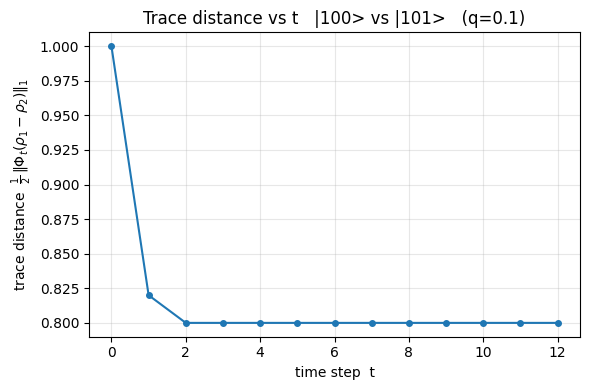

t= 0  D=1.000000
t= 1  D=0.820000
t= 2  D=0.800000
t= 3  D=0.800000
t= 4  D=0.800000
t= 5  D=0.800000
t= 6  D=0.800000
t= 7  D=0.800000
t= 8  D=0.800000
t= 9  D=0.800000
t=10  D=0.800000
t=11  D=0.800000
t=12  D=0.800000


In [9]:
# ---- Raw trace distance vs t for the optimal state pair ----
# This is the un-thresholded quantity behind the BLP measure: D(t) = 1/2 ||Phi_t(rho1-rho2)||_1.
# Markovian (CP-divisible) dynamics => D(t) monotonically non-increasing.
# Any revival (upward step) is exactly what non_markovian_measure sums.
q    = 0.1
Tmax = 12
channel = make_channel(build_all_channels(Tmax, q))

_, (i, j) = max_measure(Tmax, q)                 # optimal basis-state pair at this q
delta = basis_state(i) - basis_state(j)

ts   = list(range(0, Tmax + 1))
dist = [0.5 * trace_norm(channel(t, delta)) for t in ts]

plt.figure(figsize=(6, 4))
plt.plot(ts, dist, marker='o', ms=4)
plt.xlabel('time step  t')
plt.ylabel(r'trace distance  $\frac{1}{2}\,\|\Phi_t(\rho_1-\rho_2)\|_1$')
plt.title(f'Trace distance vs t   |{i:0{n}b}> vs |{j:0{n}b}>   (q={q})')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

for t, d in zip(ts, dist):
    print(f"t={t:2d}  D={d:.6f}")

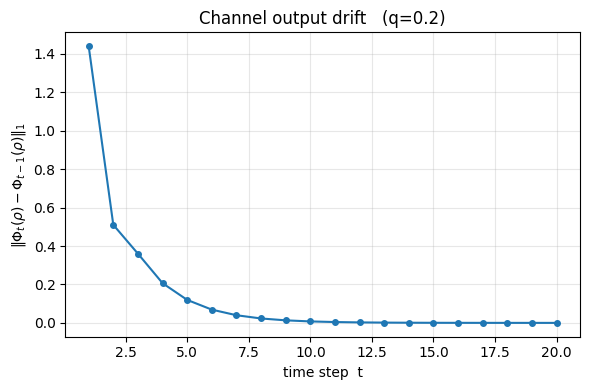

t= 1  ||dPhi(rho)||_1=1.440000
t= 2  ||dPhi(rho)||_1=0.510208
t= 3  ||dPhi(rho)||_1=0.360192
t= 4  ||dPhi(rho)||_1=0.206667
t= 5  ||dPhi(rho)||_1=0.119580
t= 6  ||dPhi(rho)||_1=0.069040
t= 7  ||dPhi(rho)||_1=0.039861
t= 8  ||dPhi(rho)||_1=0.023014
t= 9  ||dPhi(rho)||_1=0.013287
t=10  ||dPhi(rho)||_1=0.007671
t=11  ||dPhi(rho)||_1=0.004429
t=12  ||dPhi(rho)||_1=0.002557
t=13  ||dPhi(rho)||_1=0.001476
t=14  ||dPhi(rho)||_1=0.000852
t=15  ||dPhi(rho)||_1=0.000492
t=16  ||dPhi(rho)||_1=0.000284
t=17  ||dPhi(rho)||_1=0.000164
t=18  ||dPhi(rho)||_1=0.000095
t=19  ||dPhi(rho)||_1=0.000055
t=20  ||dPhi(rho)||_1=0.000032


In [10]:
# ---- Channel drift:  ||channel(t, rho) - channel(t-1, rho)||_1 ----
# Shows the dynamical map settling: this difference decays monotonically to 0 as the channel
# relaxes to its steady state. With the corrected (partial-product) family the trace distance
# is monotonically non-increasing, so there is no backflow and the BLP measure is 0.
q    = 0.2
Tmax = 20
channel = make_channel(build_all_channels(Tmax, q))

rho1 = basis_state(int('100', 2))
rho2 = basis_state(int('101', 2))                # a pure computational-basis input state
rho = rho1 - rho2

ts   = list(range(1, Tmax + 1))
diff = [trace_norm(channel(t, rho) - channel(t - 1, rho)) for t in ts]

plt.figure(figsize=(6, 4))
plt.plot(ts, diff, marker='o', ms=4)
plt.xlabel('time step  t')
plt.ylabel(r'$\|\Phi_t(\rho) - \Phi_{t-1}(\rho)\|_1$')
plt.title(f'Channel output drift   (q={q})')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

for t, d in zip(ts, diff):
    print(f"t={t:2d}  ||dPhi(rho)||_1={d:.6f}")

In [11]:
# ---- RHP (Rivas-Huelga-Plenio) CP-divisibility measure ----
# Factor the evolution as  channel(t) = M_t . channel(t-1)  with  M_t = channel(t) channel(t-1)^{-1}.
# M_t is completely positive  iff  its Choi matrix J(M_t) is positive semidefinite.
# Step non-CP-ness:  g_t = (||J(M_t)||_1 - tr J(M_t)) / dim   ( = (2/dim) * sum of |negative eigs| ),
# which is 0 iff M_t is CP. The RHP measure is sum_t g_t.
#
# Unlike the BLP (trace-distance) measure, RHP detects non-CP-divisibility even when there is
# NO distinguishability backflow -- exactly the situation for this channel (BLP = 0).
def choi(M):
    """Choi matrix J(M) = sum_ij |i><j| (x) M(|i><j|) for a superoperator M (dim^2 x dim^2)."""
    J = np.zeros((dim * dim, dim * dim), dtype=complex)
    for i in range(dim):
        for j in range(dim):
            E = np.zeros((dim, dim), dtype=complex); E[i, j] = 1.0
            J += np.kron(E, unvec(M @ vec(E)))
    return J

def rhp_measure(chans, T, cond_thresh=1e6):
    """RHP measure sum_t g_t (and the per-step list g_t, and #valid steps).

    A step is skipped once channel(t-1) is too ill-conditioned (cond > cond_thresh): there the
    inverse -- and hence CP-divisibility -- is numerically/formally undefined. The skipped tail
    contributes negligibly when the maps are well-conditioned, but note the measure SPIKES /
    DIVERGES at q-values where some channel(t) loses rank (an eigenvalue crossing 0)."""
    gs = []
    for t in range(1, T + 1):
        if np.linalg.cond(chans[t - 1]) > cond_thresh:
            break
        ev = np.linalg.eigvalsh(choi(chans[t] @ np.linalg.inv(chans[t - 1])))
        gs.append((np.sum(np.abs(ev)) - np.sum(ev).real) / dim)
    return sum(gs), gs, len(gs)

RHP measure = 0.103868   (q=0.1, T=12, 12 valid steps)
(BLP measure is 0 here, so any RHP > 0 is memory that the trace-distance measure cannot see.)
  t= 1  g_t=1.998e-15   CP
  t= 2  g_t=9.656e-02   NOT CP  -> non-divisible
  t= 3  g_t=6.633e-03   NOT CP  -> non-divisible
  t= 4  g_t=6.122e-04   NOT CP  -> non-divisible
  t= 5  g_t=5.345e-05   NOT CP  -> non-divisible
  t= 6  g_t=4.750e-06   NOT CP  -> non-divisible
  t= 7  g_t=4.193e-07   NOT CP  -> non-divisible
  t= 8  g_t=3.711e-08   NOT CP  -> non-divisible
  t= 9  g_t=3.281e-09   NOT CP  -> non-divisible
  t=10  g_t=2.902e-10   CP
  t=11  g_t=2.566e-11   CP
  t=12  g_t=2.271e-12   CP


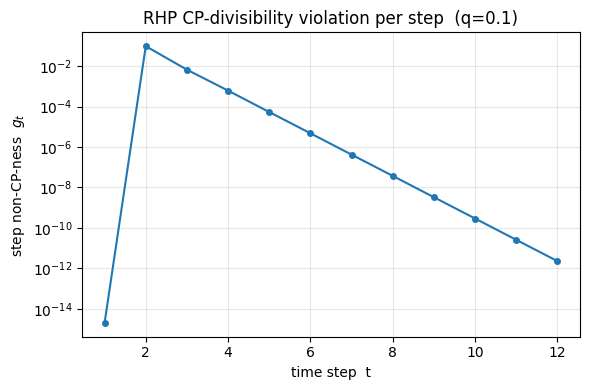

In [12]:
# ---- RHP measure at fixed q: per-step CP-divisibility violation ----
q = 0.1
T = 12
chans = build_all_channels(T, q)
total, gs, nvalid = rhp_measure(chans, T)
print(f"RHP measure = {total:.6f}   (q={q}, T={T}, {nvalid} valid steps)")
print("(BLP measure is 0 here, so any RHP > 0 is memory that the trace-distance measure cannot see.)")
for t, gt in enumerate(gs, start=1):
    tag = "CP" if gt < 1e-9 else "NOT CP  -> non-divisible"
    print(f"  t={t:2d}  g_t={gt:.3e}   {tag}")

plt.figure(figsize=(6, 4))
plt.semilogy(range(1, len(gs) + 1), [max(g, 1e-18) for g in gs], marker='o', ms=4)
plt.xlabel('time step  t')
plt.ylabel(r'step non-CP-ness  $g_t$')
plt.title(f'RHP CP-divisibility violation per step  (q={q})')
plt.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.show()

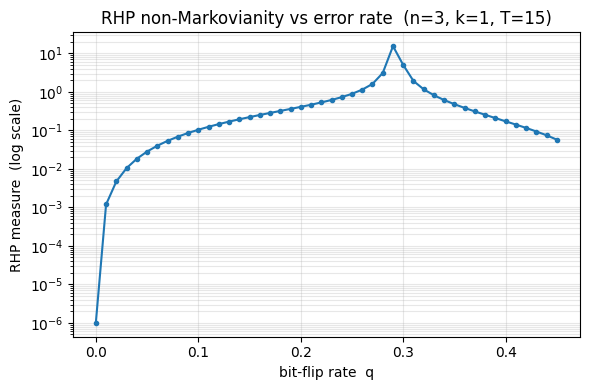

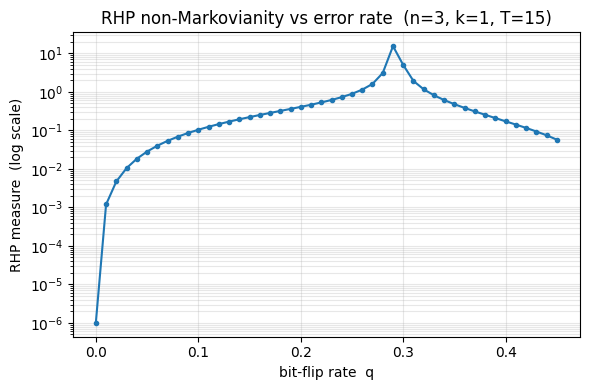

In [50]:
# ---- RHP measure vs error rate q ----
# CAVEAT: where some channel(t) becomes non-invertible -- an eigenvalue crossing 0 (e.g. Phi_1
# near q ~ 0.30) and the depolarizing limit q -> 0.5 -- the propagator M_t and thus
# CP-divisibility are formally undefined, and the measure spikes/diverges. Ill-conditioned
# steps are skipped, so the curve is reliable only in the well-conditioned (small/moderate q) region.
T  = 15
qs = np.linspace(0.0, 0.45, 46)
rhp_vals = [rhp_measure(build_all_channels(T, q), T)[0] for q in qs]

plt.figure(figsize=(6, 4))
plt.semilogy(qs, [max(v, 1e-6) for v in rhp_vals], marker='o', ms=3)
plt.xlabel('bit-flip rate  q')
plt.ylabel('RHP measure  (log scale)')
plt.title(f'RHP non-Markovianity vs error rate  (n={n}, k={k}, T={T})')
plt.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.show()